# Chartbook — expenditure by ESA economic type

The companion to [`chartbook.ipynb`](chartbook.ipynb), which explains how to
read every chart here (levels, seams, projection shading, captions). This book
holds the third tree, **expenditure by ESA economic type** (`ESA_EXP`,
D-S13-003): nine lines per country that sum to `TE_ESA`, a second cut of the
same total expenditure as the COFOG functions — so an `E` line must never be
added to a `GF` line.

| line | ESA | what it is |
|---|---|---|
| `E01` | D.1 | compensation of employees |
| `E02` | P.2 | intermediate consumption |
| `E03` | D.62 | social benefits other than social transfers in kind — every cash benefit, all functions |
| `E04` | D.632 | social transfers in kind via market producers (purchased health care, etc.) |
| `E05` | D.41 | interest payable — the economic-type twin of COFOG `GF01_7` |
| `E06` | D.3 | subsidies |
| `E07` | D.29 + D.5 + (D.4 − D.41) + D.7 + D.8 | other current expenditure |
| `E08` | P.5 + NP | gross capital formation and net acquisitions of non-produced assets |
| `E09` | D.9 | capital transfers payable |
| `TE_ESA` | total | their sum: the ESA main-aggregates total expenditure |

Sources: Eurostat `gov_10a_main` payable items for France and Germany, ONS ESA
Table 2 payable rows for the UK — the same institution as each country's
anchor, so the identity `E01 + … + E09 = TE_ESA` is exact in every outturn
year (V2). Forecasts: AMECO carries every line on the same ESA concept, so
`E01`–`E07` project to 2027 at grade A for France and Germany, and `E05`
chains into the Debt Sustainability Monitor's interest path to 2036 under
the same committee approval as `GF01_7`; the UK's compensation, intermediate
consumption and other-current lines have no AMECO history to measure
coverage on and stop at the last outturn; `E08` and `E09` have partial
components only (§7.8 proxies, `maximum_extension`). Backward, AMECO takes
the French lines to 1978, the German ones to 1991, the UK ones to 1987 where
the UK history exists.

Every caption states the recipe and how far each variant projects, exactly as
in the main book; "no projection published" and its five reasons mean the same
thing here. Each country opens with the same **forecast panel** as the main
book (D-S11-001, extended to this tree by D-S13-007): every `E` line as a share
of GDP with the one forecast this project would quote for it — the official
projection where one is published, the statistical combination with its 80%
interval where none is — and the levels charts carry the statistical benchmark
in currency (D-S11-003) wherever the strict series has no official path. The
ranked `changes()` picture and the benchmark balance stay in the main book:
the balance is built from the COFOG and revenue trees, and this tree is the
same money cut a second way.


In [1]:
import io
from pathlib import Path
from textwrap import fill

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image as Image_display, display
from PIL import Image

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "deliverables" / "series_catalogue.csv").exists())
DELIV = ROOT / "deliverables"
load = lambda n: pd.read_csv(DELIV / f"{n}.csv")

EXPENDITURE = load("expenditure_cofog")
ECONOMIC = load("expenditure_esa")   # the ESA_EXP tree, charted in chartbook_esa.ipynb
REVENUE = load("revenue_esa")
TREE = pd.concat([EXPENDITURE, ECONOMIC, REVENUE], ignore_index=True)
LEDGER = load("balance_ledger")
LEVELS = load("weo_levels_bridge")
RECON = load("weo_reconciliation")
CATALOGUE = load("series_catalogue")
FORECASTS = load("statistical_forecasts")
# the same forecasts in currency, for the levels charts: one nominal GDP
# path per country, our outturn anchored and chained on the WEO's NGDP
# growth. Built by `ggfiscal forecast-levels`; nothing is multiplied here.
FORECAST_LCU = load("forecast_levels").query("method == 'combination'")

LATEST = sorted(LEVELS.weo_vintage.dropna().unique())[-1]
NAME = dict(zip(CATALOGUE.iso3, CATALOGUE.country))

# Categorical slots 1-4 of the validated palette, assigned by entity and never
# reused: blue is always our strict series, orange always the maximum
# extension, aqua always the IMF WEO, and violet always a statistical
# forecast — the same violet the forecast books use for the same thing. Line
# style repeats the distinction so identity never rests on colour alone.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
VIOLET = "#4a3aa7"
INK, MUTED, AXIS = "#0b0b0b", "#898781", "#c3c2b7"
SURFACE, SHADE = "#fcfcfb", "#eceae4"

plt.rcParams.update({
    "figure.figsize": (6.9, 2.7), "figure.dpi": 72,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelsize": 9, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "grid.color": AXIS, "grid.alpha": 0.45, "grid.linewidth": 0.6,
    "legend.frameon": False, "legend.fontsize": 8.5,
    "lines.linewidth": 2,
})


# Every chart runs from its country's earliest published year to 2031, so any
# two can be laid side by side and read against the same calendar. 2031 is the
# end of the near-term forecast horizon; four series per country carry
# long-term legs to 2036 or 2070, and those run off the right edge with a
# marker saying how far they go. The values are all in the flat files.
XMAX = 2031
XLIM = {}
for _iso in TREE.iso3.unique():
    _years = pd.concat([TREE.query("iso3 == @_iso").year,
                        LEDGER.query("iso3 == @_iso").year])
    _lo = int(_years.min())
    _pad = (XMAX - _lo) * 0.035
    XLIM[_iso] = (_lo - _pad, XMAX + _pad)

# To read all three countries against one calendar instead of one per country,
# uncomment these two lines and re-run from here:
# _LO = min(lo for lo, _ in XLIM.values())
# XLIM = {iso: (_LO, XMAX + (XMAX - _LO) * 0.035) for iso in XLIM}


def _palette():
    """A fixed palette of exactly the colours these charts use.

    Quantising is what keeps this notebook renderable — at full colour depth
    its 100-odd figures came to 3.3 MB, at which size GitHub's notebook
    renderer gives up and shows "Loading" forever. But an *adaptive* palette
    allocates slots by pixel count, and a dashed line has few pixels: at 32
    colours it crushed the orange series to a muddy #927670. So the palette
    is fixed instead — each mark colour exactly, plus its blends toward the
    two backgrounds for antialiasing — and the brand hues survive whatever
    share of the canvas they happen to occupy.
    """
    from matplotlib.colors import to_rgb

    entries = [to_rgb(SURFACE), to_rgb(SHADE)]
    # VIOLET is appended last on purpose: adding a colour to the front of
    # this list would renumber every index and rewrite every figure in the
    # book for no change in what any of them shows.
    for mark in (INK, MUTED, AXIS, BLUE, ORANGE, AQUA, VIOLET):
        m = to_rgb(mark)
        for ground in (SURFACE, SHADE):
            g = to_rgb(ground)
            entries += [tuple(m[i] + (g[i] - m[i]) * t for i in range(3))
                        for t in (0.0, 0.2, 0.4, 0.6, 0.8)]
    flat = [round(255 * v) for e in entries for v in e]
    pal = Image.new("P", (1, 1))
    pal.putpalette(flat + [0] * (768 - len(flat)))
    return pal


PALETTE = _palette()


def show(fig):
    """Display a figure as a PNG quantised onto that fixed palette."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=plt.rcParams["figure.dpi"])
    plt.close(fig)
    small = Image.open(buf).convert("RGB").quantize(
        palette=PALETTE, dither=Image.Dither.NONE)
    out = io.BytesIO()
    small.save(out, format="PNG", optimize=True)
    display(Image_display(data=out.getvalue()))


def thousands(ax):
    """Levels run to seven figures; unseparated tick labels are unreadable."""
    ax.yaxis.set_major_formatter(
        plt.matplotlib.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))


def _seams(g):
    """Years where the source or the construction method changes."""
    g = g.sort_values("year")
    key = list(zip(g.observation_type, g.source_id.fillna("")))
    return [int(y) for (a, b), y in zip(zip(key, key[1:]), g.year[1:]) if a != b]


# Why a series carries no projection. The pipeline records one of five
# statuses per undeclared line; these are the plain-language readings.
WHY_NO_FORECAST = {
    "no_official_forecast":
        "nobody publishes a forecast of this line on a compatible concept",
    "source_blocked":
        "a forecast exists but the publication cannot be ingested",
    "grade_below_strict":
        "the only candidate covers too little of the line to enter strict",
    "no_machine_readable_source":
        "the candidate source has no ESA-complete machine-readable series",
    "not_extended":
        "a total, deliberately not given a forecast path of its own",
}


def _forecast_lines(row):
    """State, in words, how far each variant projects and why it stops."""
    actual = int(row.final_actual_year)
    out = [f"outturn:  {int(row.first_year)}-{actual}"]
    # the recorded reason is prefixed with its own [status] tag, which reads
    # oddly on a line that says the variant does project; the status is said
    # in words below anyway
    untag = lambda t: t.split("] ", 1)[1] if t.startswith("[") else t
    reason = untag(row.reason_series_ends) if isinstance(
        row.reason_series_ends, str) else ""
    note = row.forecast_note if isinstance(row.forecast_note, str) else ""
    status = row.forecast_status if isinstance(row.forecast_status, str) else ""
    headline = WHY_NO_FORECAST.get(status, "")

    def say(end):
        if end > actual:
            return f"projects to {end} — {reason or 'source horizon'}"
        why = note or reason or "no forecast source identified"
        return f"NO PROJECTION — {headline or 'see note'}. {why}"

    strict, maximum = say(int(row.final_strict_year)), say(int(row.final_maximum_year))
    if strict == maximum:                       # the common case: say it once
        out.append(f"{'both:'.ljust(9)} {strict}")
    else:
        out.append(f"{'strict:'.ljust(9)} {strict}")
        out.append(f"{'maximum:'.ljust(9)} {maximum}")
    return out


def _benchmark_caption(iso3, line_code):
    """The statistical leg, said in the same voice as the recipe above it."""
    f = FORECAST_LCU.query("iso3 == @iso3 and line_code == @line_code")
    if f.empty:
        return []
    end = f.sort_values("year").iloc[-1]
    return [f"benchmark: statistical combination of auto.arima, ets, prophet "
            f"and uc to {int(end.year)} — {end.value_lcu_mn:,.0f} "
            f"{end.currency} mn (80% {end.lo80_lcu_mn:,.0f} to "
            f"{end.hi80_lcu_mn:,.0f}), on GDP {end.gdp_basis} from "
            f"{int(end.gdp_anchor_year)}. Fitted on outturn only; a benchmark, "
            f"not a published forecast."]


def _caption(iso3, line_code):
    row = CATALOGUE.query("iso3 == @iso3 and line_code == @line_code").iloc[0]
    recipe = str(row.recipe_maximum_extension).replace(" | ", "  ·  ")
    parts = [fill(f"recipe:   {recipe}", 104, subsequent_indent=" " * 10)]
    lines = _forecast_lines(row)
    # only where the strict series carries no official projection — where one
    # exists it is the number, exactly as in the forecast panels
    if int(row.final_strict_year) <= int(row.final_actual_year):
        lines += _benchmark_caption(iso3, line_code)
    parts += [fill(line, 104, subsequent_indent=" " * 10) for line in lines]
    return "\n".join(parts)


def chart(iso3, line_code, caption=True, xlim=None):
    """One series, both variants, with its seams and projection region.

    `xlim` overrides the shared country axis to zoom in on a stretch.
    """
    g = TREE.query("iso3 == @iso3 and line_code == @line_code")
    strict = g.query("variant == 'strict'").sort_values("year")
    mx = g.query("variant == 'maximum_extension'").sort_values("year")
    label = g.line_label.iloc[0]
    actual = g.query("basis == 'actual'").year.max()
    furthest = int(mx.year.max())

    fig, ax = plt.subplots()
    # The projection region is shaded on every chart, whether or not the
    # series reaches into it: a line that stops at the shading edge is one
    # nobody publishes a forecast for, and that should look different from a
    # line that carries on.
    lo, hi = xlim or XLIM[iso3]
    ax.set_xlim(lo, hi)
    ax.axvspan(actual, hi, color=SHADE, zorder=0, lw=0)
    # Plot only what the window shows, plus one point past the edge so the
    # line reaches it. Without this the y-axis would autoscale to values that
    # are not on the chart, flattening everything that is.
    window = lambda d: d[d.year <= hi + 1]
    if len(mx) > len(strict):
        ax.plot(window(mx).year, window(mx).value_lcu_mn, color=ORANGE,
                ls="--", label="maximum_extension")
    ax.plot(window(strict).year, window(strict).value_lcu_mn, color=BLUE,
            label="strict")
    # The statistical benchmark, in currency, where nobody publishes a
    # forecast of this line. Where an official projection exists it is the
    # number and this is not drawn — the same rule as the forecast panels.
    # 80% only: the 95% band swamps a levels axis, and it is in the forecast
    # books where it belongs.
    bench = FORECAST_LCU.query("iso3 == @iso3 and line_code == @line_code and "
                               "year <= @hi").sort_values("year")
    # Keyed on STRICT, and anchored on strict's own last outturn — not on
    # `actual`, which comes from both variants and can be a year later where
    # maximum_extension carries a stitched 2025 the strict series does not.
    # A maximum_extension proxy leg is not an official forecast, so a line
    # that has one still gets the benchmark. Same test the caption uses.
    strict_actual = strict[strict.basis == "actual"]
    drew_benchmark = (int(strict.year.max()) <= actual and len(bench)
                      and len(strict_actual))
    if drew_benchmark:
        anchor_year = int(strict_actual.year.max())
        anchor = float(strict_actual.value_lcu_mn.iloc[-1])
        years = [anchor_year, *bench.year]
        ax.fill_between(years, [anchor, *bench.lo80_lcu_mn],
                        [anchor, *bench.hi80_lcu_mn], color=VIOLET,
                        alpha=0.18, lw=0, zorder=1, label="benchmark 80%")
        ax.plot(years, [anchor, *bench.value_lcu_mn], color=VIOLET, ls="--",
                zorder=4, label="statistical benchmark")
    for year in _seams(mx):
        ax.axvline(year, color=MUTED, ls=":", lw=0.9, alpha=0.8, zorder=1)
    if furthest <= actual and not drew_benchmark:
        ax.annotate("no projection published", (actual, 0.94),
                    xycoords=("data", "axes fraction"),
                    xytext=(4, 0), textcoords="offset points",
                    color=MUTED, fontsize=7.5, va="top")
    elif furthest > hi:
        ax.annotate(f"continues to {furthest} →", (hi, 0.94),
                    xycoords=("data", "axes fraction"),
                    xytext=(-4, 0), textcoords="offset points",
                    color=MUTED, fontsize=7.5, va="top", ha="right")

    ax.set_title(f"{NAME[iso3]} · {line_code} — {label}")
    ax.set_ylabel(f"{g.currency.iloc[0]} mn")
    ax.grid(axis="y")
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    thousands(ax)
    if len(mx) > len(strict) or drew_benchmark:
        ax.legend(loc="upper left", ncol=2 if drew_benchmark else 1)
    fig.tight_layout()
    show(fig)
    if caption:
        print(_caption(iso3, line_code))


def ledger_chart(iso3, quantity, xlim=None):
    """One balance-ledger quantity. Outturn only; the variants are identical."""
    g = LEDGER.query("iso3 == @iso3 and variant == 'strict'").sort_values("year")
    col = f"{quantity.lower()}_lcu_mn"
    meaning = {"TR": "total revenue (balance anchor's own total)",
               "TE": "total expenditure (balance anchor's own total)",
               "NLB": "net lending (+) / net borrowing (-) = TR - TE",
               "NI": "net interest = GF01_7 - R07",
               "PB": "primary balance = NLB + NI"}[quantity]

    actual = int(g.year.max())
    fig, ax = plt.subplots()
    lo, hi = xlim or XLIM[iso3]
    ax.set_xlim(lo, hi)
    ax.axvspan(actual, hi, color=SHADE, zorder=0, lw=0)
    ax.plot(g.year, g[col], color=BLUE)
    if (g[col] < 0).any():
        ax.axhline(0, color=AXIS, lw=1, zorder=0)
    ax.annotate("no projection published", (actual, 0.94),
                xycoords=("data", "axes fraction"),
                xytext=(4, 0), textcoords="offset points",
                color=MUTED, fontsize=7.5, va="top")
    ax.set_title(f"{NAME[iso3]} · ledger {quantity} — {meaning}")
    ax.set_ylabel(f"{g.currency.iloc[0]} mn")
    ax.grid(axis="y")
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    thousands(ax)
    fig.tight_layout()
    show(fig)
    missing = g[g[col].isna()].year.tolist()
    print(f"outturn:  {int(g.year.min())}-{actual}, source {g.source_id.iloc[0]}"
          + (f"; no value for {missing}" if missing else ""))
    print(fill("forecast: NO PROJECTION — the ledger is outturn-only by "
               "design. Building it forward would mean summing lines whose "
               "forecast coverage is partial, which would misstate the "
               "totals; the forecast-side comparison lives in section 4 "
               "instead, where the coverage gap is explicit.", 104,
               subsequent_indent=" " * 10))


WEO_Q = {
    "revenue": ("tr_ours_mn", "tr_weo_mn", "gap_tr_pct_te",
                "total revenue", "WEO GGR"),
    "expenditure": ("te_ours_mn", "te_weo_mn", "gap_te_pct_te",
                    "total expenditure", "WEO GGX"),
    "nlb": ("nlb_ours_mn", "nlb_weo_mn", "gap_nlb_pct_te",
            "net lending / borrowing", "WEO GGXCNL"),
}


def weo_chart(iso3, quantity, vintage=None):
    """Ours against the IMF WEO, level and gap, over the overlap years."""
    vintage = vintage or LATEST
    ours_col, weo_col, gap_col, label, weo_label = WEO_Q[quantity]
    g = (LEVELS.query("block == 'history' and iso3 == @iso3 and "
                      "weo_vintage == @vintage").sort_values("year"))
    currency = LEDGER.query("iso3 == @iso3").currency.iloc[0]

    fig, (ax, gx) = plt.subplots(2, 1, figsize=(6.6, 3.8), sharex=True,
                                 height_ratios=[2.6, 1])
    ax.plot(g.year, g[ours_col], color=BLUE, label="ours")
    ax.plot(g.year, g[weo_col], color=AQUA, ls="--", label=weo_label)
    if (g[ours_col] < 0).any():
        ax.axhline(0, color=AXIS, lw=1, zorder=0)

    # Same country axis as sections 1-3, so this chart can be read against
    # them. The comparison itself ends at the last outturn, because our
    # ledger does; the years after it are the shaded projection region with
    # nothing on our side to put in it.
    ax.set_xlim(*XLIM[iso3])
    ax.axvspan(g.year.max(), XLIM[iso3][1], color=SHADE, zorder=0, lw=0)
    ax.annotate("no projection published", (g.year.max(), 0.04),
                xycoords=("data", "axes fraction"),
                xytext=(4, 0), textcoords="offset points",
                color=MUTED, fontsize=7.5, va="bottom")

    # Direct labels: the aqua step sits below 3:1 on this surface, so identity
    # is carried by text on the mark as well as by the legend. The two series
    # nearly coincide by construction, so the labels are staggered off each
    # other rather than drawn on top of one another.
    ends = [(ours_col, BLUE, "ours"), (weo_col, AQUA, weo_label)]
    lo, hi = ax.get_ylim()
    close = abs(g[ours_col].iloc[-1] - g[weo_col].iloc[-1]) < (hi - lo) * 0.06
    for (col, colour, text), dy in zip(ends, (9, -9) if close else (0, 0)):
        y = g[col].iloc[-1]
        # keep the label inside the axes: near the top it would otherwise ride
        # up into the title
        if (y - lo) / (hi - lo) > 0.86:
            dy -= 16
        ax.annotate(text, (g.year.iloc[-1], y),
                    xytext=(6, dy), textcoords="offset points",
                    color=colour, fontsize=8.5, va="center")
    ax.set_title(f"{NAME[iso3]} · {label} — ours vs IMF WEO")
    ax.set_ylabel(f"{currency} mn")
    ax.grid(axis="y")
    thousands(ax)
    ax.legend(loc="upper left")

    gx.plot(g.year, g[gap_col], color=BLUE)
    gx.axhline(0, color=AXIS, lw=1, zorder=0)
    gx.set_ylabel("gap, % of TE")
    gx.grid(axis="y")
    gx.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    fig.tight_layout()
    show(fig)

    gap = g[gap_col]
    kinds = ", ".join(sorted(g.gap_classification.dropna().unique()))
    print(f"WEO vintage {vintage}; overlap {int(g.year.min())}-"
          f"{int(g.year.max())}; gap mean {gap.mean():+.3f}% of TE, "
          f"sigma {gap.std():.3f}, range {gap.min():+.3f} to "
          f"{gap.max():+.3f}; classified: {kinds}")


print(f"loaded {len(TREE):,} tree rows, {len(LEDGER)} ledger rows, "
      f"{len(LEVELS)} bridge rows, {len(FORECASTS):,} statistical "
      f"forecast rows ({len(FORECAST_LCU):,} of them also in currency); "
      f"WEO vintages "
      f"{', '.join(sorted(LEVELS.weo_vintage.dropna().unique()))}; "
      f"latest {LATEST}")

loaded 10,544 tree rows, 196 ledger rows, 398 bridge rows, 3,610 statistical forecast rows (722 of them also in currency); WEO vintages 2025-04, 2025-10, 2026-04; latest 2026-04


In [2]:
# --------------------------------------------------------------- the panels
#
# Sections 1-3 give each series a chart of its own, in levels. Each country
# section opens instead with a panel: every category of that country on one
# page, as a share of GDP, each carrying the single forecast this project
# would quote for it. One rule decides which forecast that is:
#
#     an official projection exists  ->  draw it, blue dashed, no band
#     none exists                    ->  draw the statistical `combination`,
#                                        violet dashed, with its 80% interval
#
# `combination` is the fifth method in `statistical_forecasts.csv`: the mean
# of auto.arima, ets, prophet and uc, with a standard error carrying both the
# average within-model variance and the variance across the four point
# forecasts, so it widens when the methods disagree. One line stands for all
# four; the four are never drawn separately here. `forecasts_*.ipynb` is
# where they are compared one by one, and where a statistical path is put
# beside an official one on the same axes. This book does not do that: where
# an official projection exists it is the number, and the benchmark is not
# drawn against it.
#
# Nothing is spliced and nothing is recomputed. Every path — official or
# statistical — is anchored at its own line's last outturn, so the year a
# forward line leaves the blue history is that line's last actual year. The
# values are read straight out of the flat files.

PANEL_FROM = 2000        # fan charts are illegible on a 1965 axis
TOTALS = ("TE", "TR", "TE_ESA")    # envelopes, not categories, and never forecast
TREE_OF = {"economic": (ECONOMIC, "ESA economic type")}


def _panel_codes(iso3, tree):
    src, _ = TREE_OF[tree]
    return sorted(c for c in src.query("iso3 == @iso3 and variant == 'strict'")
                  .line_code.unique() if c not in TOTALS)


def _forward(iso3, line_code):
    """The one forecast this book quotes for a line, and where it came from.

    Returns the outturn, its last year and value (the anchor every forward
    path starts from), the path itself, which of the two sources it is, and
    how far that source runs before the 2031 axis cuts it off.
    """
    g = TREE.query("iso3 == @iso3 and line_code == @line_code and "
                   "variant == 'strict'").dropna(subset=["pct_gdp"])
    hist = g[g.basis == "actual"].sort_values("year")
    anchor_year, anchor = int(hist.year.max()), float(hist.pct_gdp.iloc[-1])

    official = g[g.basis == "forecast"].sort_values("year")
    if len(official) and (official.year <= XMAX).any():
        return (hist, anchor_year, anchor, official[official.year <= XMAX],
                "official", int(official.year.max()))

    combination = FORECASTS.query(
        "iso3 == @iso3 and line_code == @line_code and "
        "method == 'combination'").sort_values("year")
    if combination.empty:
        return hist, anchor_year, anchor, None, "none", anchor_year
    return (hist, anchor_year, anchor, combination, "statistical",
            int(combination.year.max()))


def _pp(value, dp=1):
    """A signed change in percentage points. A change that rounds to nothing
    is shown as ±0.0: `-0.0` reads as a fall that the number does not
    support, and on these panels most lines round to nothing."""
    if abs(round(value, dp)) == 0:
        return f"\u00b10.{'0' * dp}"
    return f"{value:+.{dp}f}"


# The readout goes in the emptiest corner of the facet, left ones preferred:
# a number that sits on the line it describes is a number nobody reads.
CORNERS = [(0.02, 0.97, "left", "top"), (0.02, 0.03, "left", "bottom"),
           (0.98, 0.97, "right", "top"), (0.98, 0.03, "right", "bottom")]


def _label_corner(ax, xs, ys, width=0.46, height=0.24):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    fx = [(x - x0) / (x1 - x0) for x in xs]
    fy = [(y - y0) / (y1 - y0) for y in ys]
    best, fewest = CORNERS[0], None
    for corner in CORNERS:
        _, _, ha, va = corner
        lo_x, hi_x = (0, width) if ha == "left" else (1 - width, 1)
        lo_y, hi_y = (1 - height, 1) if va == "top" else (0, height)
        n = sum(lo_x <= a <= hi_x and lo_y <= b <= hi_y
                for a, b in zip(fx, fy))
        if fewest is None or n < fewest:
            best, fewest = corner, n
        if not n:
            break
    return best


def _facet(ax, iso3, line_code, label):
    """One category: its share of GDP since 2000, and the one path forward."""
    hist, anchor_year, anchor, path, source, runs_to = _forward(iso3, line_code)
    # As everywhere in this book, the window is applied to the DATA and not
    # only to set_xlim: matplotlib autoscales y over everything plotted, so a
    # 2070 value left in would flatten the visible history to nothing.
    seen = hist[hist.year >= PANEL_FROM]
    ax.set_xlim(PANEL_FROM - 0.8, XMAX + 0.8)
    ax.axvspan(anchor_year, XMAX + 0.8, color=SHADE, zorder=0, lw=0)
    if path is not None and len(path):
        years = [anchor_year, *path.year]
        if source == "statistical":
            ax.fill_between(years, [anchor, *path.lo80], [anchor, *path.hi80],
                            color=VIOLET, alpha=0.20, lw=0, zorder=1)
        # the no-change line: without it the eye reads the forecast against
        # the axis, and a 0.1pp drift looks like whatever the autoscale says
        ax.plot([anchor_year, XMAX], [anchor, anchor], color=AXIS, lw=0.9,
                zorder=2)
        ax.plot(years, [anchor, *path.pct_gdp], ls="--", zorder=4,
                color=BLUE if source == "official" else VIOLET)
    ax.plot(seen.year, seen.pct_gdp, color=BLUE, zorder=3)

    # two title lines always, so the facets line up whatever the label length
    title = fill(f"{line_code} — {label}", 30).splitlines()[:2]
    ax.set_title("\n".join(title + [""] * (2 - len(title))), fontsize=8, pad=3)
    ax.grid(axis="y")
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    ax.tick_params(labelsize=7)
    # headroom for the readout below: without it the emptiest corner of a
    # facet is still often on top of the line it is describing
    bottom, top = ax.get_ylim()
    ax.set_ylim(bottom, top + (top - bottom) * 0.16)
    if path is None or not len(path):
        return
    end = int(path.year.iloc[-1])
    change = float(path.pct_gdp.iloc[-1]) - anchor
    xs, ys = [*seen.year, *path.year], [*seen.pct_gdp, *path.pct_gdp]
    if source == "statistical":
        xs += [*path.year, *path.year]
        ys += [*path.lo80, *path.hi80]
    cx, cy, ha, va = _label_corner(ax, xs, ys)
    say = f"{_pp(change)} pp to {end}"
    if runs_to > XMAX:          # the axis stops at 2031; the source does not
        say += f"\n(official runs to {runs_to})"
    ax.text(cx, cy, say, transform=ax.transAxes, ha=ha, va=va, fontsize=7,
            color=INK, linespacing=1.35)


def panel(iso3, tree, cols=3):
    """Every category of one country and tree, forward, on one page."""
    codes = _panel_codes(iso3, tree)
    src, what = TREE_OF[tree]
    labels = dict(zip(src.line_code, src.line_label))
    rows = -(-len(codes) // cols)
    head, row_height = 0.62, 1.78
    height = row_height * rows + head

    fig, axes = plt.subplots(rows, cols, figsize=(7.4, height))
    for ax, code in zip(axes.flat, codes):
        _facet(ax, iso3, code, labels[code])
    for ax in list(axes.flat)[len(codes):]:
        ax.set_visible(False)

    line = plt.matplotlib.lines.Line2D
    fig.legend(handles=[
        line([], [], color=BLUE, label="outturn"),
        line([], [], color=BLUE, ls="--", label="official forecast"),
        line([], [], color=VIOLET, ls="--", label="statistical combination"),
        plt.matplotlib.patches.Patch(color=VIOLET, alpha=0.20,
                                     label="80% interval"),
        line([], [], color=AXIS, lw=0.9, label="last outturn level")],
        loc="upper left", bbox_to_anchor=(0.012, 1 - 0.30 / height), ncol=5,
        fontsize=8, handlelength=1.8, columnspacing=1.4)
    fig.suptitle(f"{NAME[iso3]} · {tree} as % of GDP — one forecast per "
                 f"line to {XMAX}", fontsize=10.5, fontweight="bold",
                 x=0.012, ha="left", y=1 - 0.055 / height)
    fig.tight_layout(rect=(0, 0, 1, 1 - head / height))
    show(fig)

    counted = [_forward(iso3, c)[4] for c in codes]
    print(f"{len(codes)} lines, one per {what}, from {PANEL_FROM}: "
          f"{counted.count('official')} carry an official projection, "
          f"{counted.count('statistical')} take the statistical combination"
          + (f", {counted.count('none')} have neither"
             if counted.count("none") else "")
          + ". Levels, seams and the recipe behind each line are in the "
            "per-series charts below.")


def _changes(iso3):
    """Every line's forecast change in pp of GDP, and where it came from."""
    rows = []
    for tree in TREE_OF:
        labels = dict(zip(TREE_OF[tree][0].line_code,
                          TREE_OF[tree][0].line_label))
        for code in _panel_codes(iso3, tree):
            hist, anchor_year, anchor, path, source, runs_to = _forward(iso3, code)
            if path is None or not len(path):
                continue
            rows.append(dict(
                tree=tree, line_code=code, line_label=labels[code],
                outturn_year=anchor_year, outturn=anchor,
                horizon=int(path.year.iloc[-1]),
                forecast=float(path.pct_gdp.iloc[-1]),
                change_pp=float(path.pct_gdp.iloc[-1]) - anchor,
                source=source, source_runs_to=runs_to))
    return pd.DataFrame(rows)


def changes(iso3, label_top=4):
    """The panel as a single ranked picture: what each line is forecast to do.

    Expenditure and revenue are ranked separately and share one x-axis. They
    have to be separated: a rise is a rise in both blocks, but it moves the
    balance in opposite directions, and one merged ranking would invite
    exactly that misreading.
    """
    d = _changes(iso3)
    trees = [t for t in TREE_OF if (d.tree == t).any()]
    counts = [int((d.tree == t).sum()) for t in trees]
    head = 0.52
    height = 0.255 * sum(counts) + 0.55 * len(trees) + 0.75
    fig, axes = plt.subplots(len(trees), 1, figsize=(7.4, height),
                             height_ratios=counts, sharex=True)
    span = float(d.change_pp.abs().max()) * 1.32

    for ax, tree in zip(axes, trees):
        g = d[d.tree == tree].sort_values("change_pp")
        # label the movers, not every bar, and rank them within their own
        # block: the two blocks are on one x-axis but they are not one list
        big = g.change_pp.abs().nlargest(label_top).min()
        ax.barh(range(len(g)), g.change_pp, height=0.62, lw=0,
                color=[BLUE if s == "official" else VIOLET for s in g.source])
        ax.set_yticks(range(len(g)))
        ax.set_yticklabels(
            [f"{r.line_code}  {r.line_label}"
             + ("" if r.horizon == XMAX else f"  · to {r.horizon}")
             for r in g.itertuples()], fontsize=7.5)
        ax.axvline(0, color=AXIS, lw=1, zorder=0)
        ax.set_xlim(-span, span)
        ax.set_ylim(-0.7, len(g) - 0.3)
        ax.grid(axis="x")
        ax.set_axisbelow(True)
        ax.set_title(f"{tree} — {len(g)} lines", fontsize=9)
        ax.tick_params(length=0)
        for i, r in enumerate(g.itertuples()):
            if abs(r.change_pp) >= big:
                ax.annotate(_pp(r.change_pp), (r.change_pp, i),
                            xytext=(4 if r.change_pp >= 0 else -4, 0),
                            textcoords="offset points", fontsize=7.5,
                            color=INK, va="center",
                            ha="left" if r.change_pp >= 0 else "right")
    axes[-1].set_xlabel("change in % of GDP, last outturn to the line's "
                        "horizon")
    patch = plt.matplotlib.patches.Patch
    fig.legend(handles=[patch(color=BLUE, label="official forecast"),
                        patch(color=VIOLET, label="statistical combination")],
               loc="upper left", bbox_to_anchor=(0.012, 1 - 0.30 / height),
               ncol=2, fontsize=8)
    fig.suptitle(f"{NAME[iso3]} · what the forecasts change",
                 fontsize=10.5, fontweight="bold", x=0.012, ha="left",
                 y=1 - 0.055 / height)
    fig.tight_layout(rect=(0, 0, 1, 1 - head / height))
    show(fig)

    # the same numbers as a table, since a bar length is not a value
    print(f"{'line':8s} {'category':40s} {'last outturn':>16s} "
          f"{'forecast':>16s} {'change':>7s}  source")
    for r in d.sort_values(["tree", "line_code"]).itertuples():
        print(f"{r.line_code:8s} {r.line_label[:40]:40s} "
              f"{r.outturn:9.2f} ({r.outturn_year}) "
              f"{r.forecast:9.2f} ({r.horizon}) {_pp(r.change_pp, 2):>7s}  "
              f"{r.source}"
              + (f" (runs to {r.source_runs_to})"
                 if r.source_runs_to > XMAX else ""))
    # GF01 = GF01_7 + GF01_X is an identity in the trees, but the three
    # lines here can each take their forecast from a different source, and a
    # statistical fit of GF01 knows nothing about an official projection of
    # the interest line inside it. Say so with the arithmetic, not in the
    # abstract: France is off by two points of GDP on it.
    parts = d.set_index("line_code").change_pp
    identity = ""
    if {"GF01", "GF01_7", "GF01_X"} <= set(parts.index):
        whole, interest, ex = (parts.GF01, parts.GF01_7, parts.GF01_X)
        how = d.set_index("line_code").source
        identity = (f" Here GF01_7 {_pp(interest, 2)} ({how.GF01_7}) and "
                    f"GF01_X {_pp(ex, 2)} ({how.GF01_X}) come to "
                    f"{_pp(interest + ex, 2)}, against GF01\u2019s own "
                    f"{_pp(whole, 2)} ({how.GF01}) \u2014 a gap of "
                    f"{abs(interest + ex - whole):.2f} pp.")
    print(fill("GF01 is GF01_7 + GF01_X as an identity, but the three lines "
               "need not agree here: each takes its forecast from its own "
               "source, and a statistical fit of the whole knows nothing "
               "about an official projection of the interest line inside it."
               + identity + " Read them as three answers to the same "
               "question, not as a decomposition that adds up. Nor do the two "
               "blocks net: a rise in expenditure and a rise in revenue of "
               "the same size move the balance in opposite directions, and "
               "\u00a74.4 is where the balance side is decomposed properly.",
               104))


_census = pd.concat([_changes(iso).assign(iso3=iso) for iso in NAME])
print(f"forecast panels ready: {len(_census)} lines across "
      f"{_census.iso3.nunique()} countries — "
      f"{int((_census.source == 'official').sum())} carry an official "
      f"projection, {int((_census.source == 'statistical').sum())} take the "
      f"statistical combination; horizons "
      f"{int(_census.horizon.min())}-{int(_census.horizon.max())}.")


forecast panels ready: 27 lines across 3 countries — 18 carry an official projection, 9 take the statistical combination; horizons 2027-2031.


## 1. United Kingdom — expenditure by ESA economic type

The forecast panel first, then nine economic lines and their total. `E03` (cash social benefits) and `E05` (interest) are the two that other publications forecast directly; read `E05` against `GF01_7` in the main book.

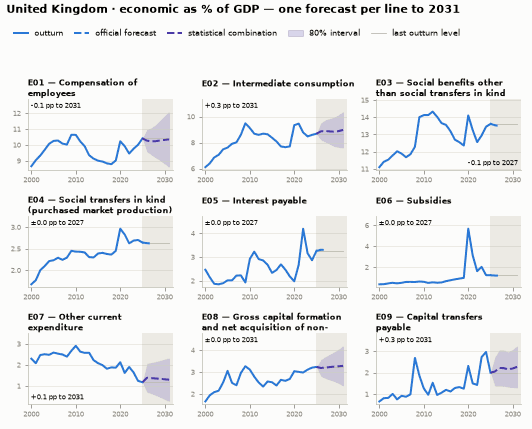

9 lines, one per ESA economic type, from 2000: 4 carry an official projection, 5 take the statistical combination. Levels, seams and the recipe behind each line are in the per-series charts below.


In [3]:
panel("GBR", "economic")

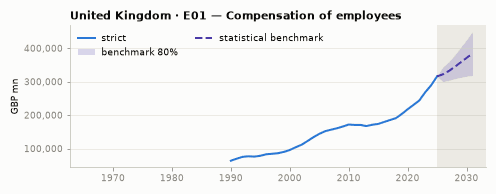

recipe:   1990-2025: anchor outturn (ONS_GG_RECEIPTS, grade A)
outturn:  1990-2025
both:     NO PROJECTION — the candidate source has no ESA-complete machine-readable series. AMECO
          publishes UK compensation of employees (UWCG) for 2026-27 only, with no history to measure
          §9.2 coverage on (OQ-4 pattern) — recorded, not applied; the EFO's economic breakdown (table
          6.1) starts at FY 2025-26, same problem
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 383,881 GBP mn (80%
          318,775 to 448,987), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [4]:
chart("GBR", "E01")

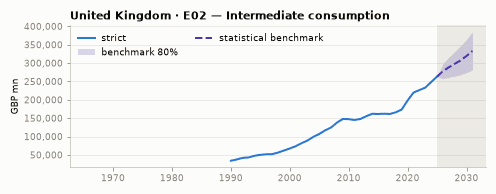

recipe:   1990-2025: anchor outturn (ONS_GG_RECEIPTS, grade A)
outturn:  1990-2025
both:     NO PROJECTION — the candidate source has no ESA-complete machine-readable series. as E01:
          AMECO UCTGI carries no UK history; EFO 6.1 procurement starts at FY 2025-26
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 333,122 GBP mn (80%
          281,122 to 385,122), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [5]:
chart("GBR", "E02")

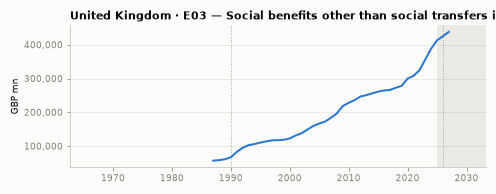

recipe:   1987-1989: backward stitch (EC_AMECO, grade B)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1987-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [6]:
chart("GBR", "E03")

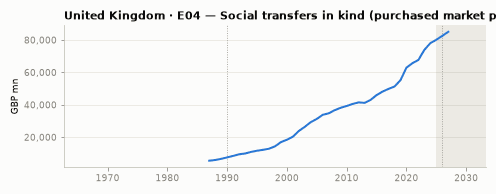

recipe:   1987-1989: backward stitch (EC_AMECO, grade B)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1987-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [7]:
chart("GBR", "E04")

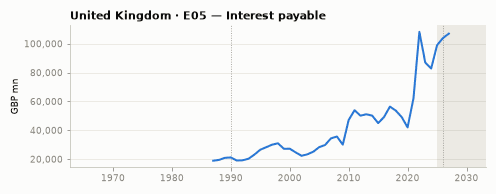

recipe:   1987-1989: backward stitch (EC_AMECO, grade B)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2027: official forecast (EC_AMECO, grade B)
outturn:  1987-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [8]:
chart("GBR", "E05")

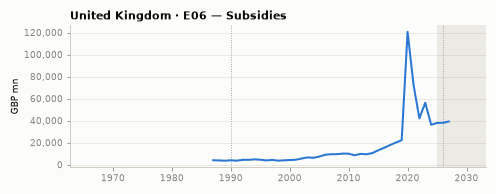

recipe:   1987-1989: backward stitch (EC_AMECO, grade B)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2027: official forecast (EC_AMECO, grade B)
outturn:  1987-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [9]:
chart("GBR", "E06")

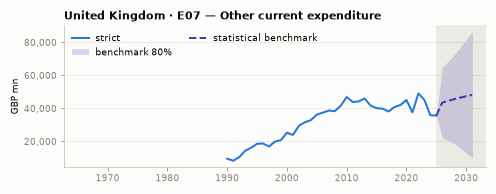

recipe:   1990-2025: derived by identity (ONS_GG_RECEIPTS, grade A)
outturn:  1990-2025
both:     NO PROJECTION — the candidate source has no ESA-complete machine-readable series. as E01:
          AMECO UUOG carries no UK history
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 48,185 GBP mn (80% 9,951
          to 86,418), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn only; a
          benchmark, not a published forecast.


In [10]:
chart("GBR", "E07")

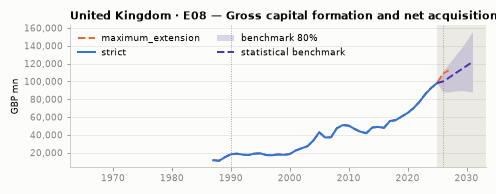

recipe:   1987-1989: backward stitch (EC_AMECO, grade B)  ·  1990-2025: derived by identity
          (ONS_GG_RECEIPTS, grade A)  ·  2026-2027: proxy forecast (EC_AMECO, grade B)
outturn:  1987-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict. AMECO UIGG0
          is gross fixed capital formation (P.51G) only — one component of P.5 + NP; §7.8 single-
          component proxy, applied in maximum_extension to 2027 with the measured share; no official
          forecast of inventories/valuables/non-produced assets exists
maximum:  projects to 2027 — AMECO UIGG0 is gross fixed capital formation (P.51G) only — one component
          of P.5 + NP; §7.8 single-component proxy, applied in maximum_extension to 2027 with the
          measured share; no official forecast of inventories/valuables/non-produced assets exists
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 121,766 GBP mn (80%
          87,911 to 155,622

In [11]:
chart("GBR", "E08")

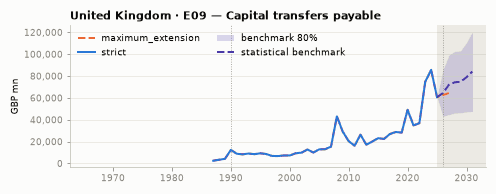

recipe:   1987-1989: backward stitch (EC_AMECO, grade B)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2027: proxy forecast (EC_AMECO, grade B)
outturn:  1987-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict. AMECO UKTGT
          (D.9 exactly) stops at the last actual; UKOG (other capital expenditure incl. capital
          transfers) is the forecast candidate — a superset proxy (§7.8), maximum_extension only where
          its measured share is in band
maximum:  projects to 2027 — AMECO UKTGT (D.9 exactly) stops at the last actual; UKOG (other capital
          expenditure incl. capital transfers) is the forecast candidate — a superset proxy (§7.8),
          maximum_extension only where its measured share is in band
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 84,158 GBP mn (80%
          47,817 to 120,500), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on

In [12]:
chart("GBR", "E09")

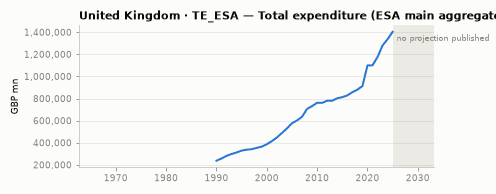

recipe:   1990-2025: anchor outturn (ONS_GG_RECEIPTS, grade A)
outturn:  1990-2025
both:     NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): the same TE envelope constrains the ESA_EXP forecast sum in V15; not
          published as a stitched path


In [13]:
chart("GBR", "TE_ESA")

## 2. France — expenditure by ESA economic type

The forecast panel first, then nine economic lines and their total. `E03` (cash social benefits) and `E05` (interest) are the two that other publications forecast directly; read `E05` against `GF01_7` in the main book.

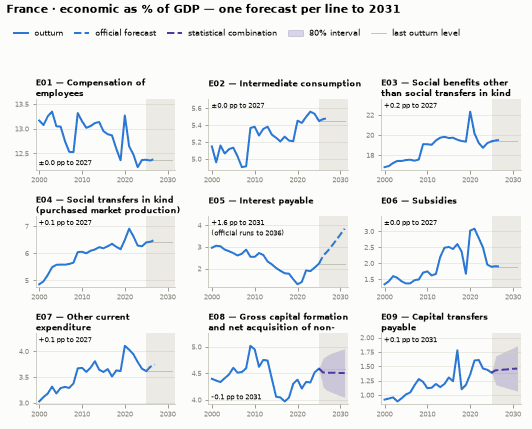

9 lines, one per ESA economic type, from 2000: 7 carry an official projection, 2 take the statistical combination. Levels, seams and the recipe behind each line are in the per-series charts below.


In [14]:
panel("FRA", "economic")

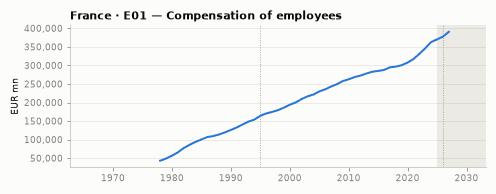

recipe:   1978-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1978-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [15]:
chart("FRA", "E01")

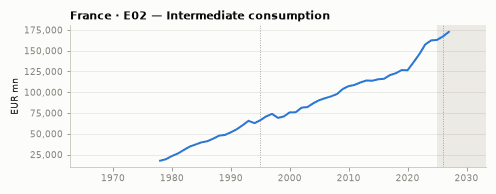

recipe:   1978-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1978-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [16]:
chart("FRA", "E02")

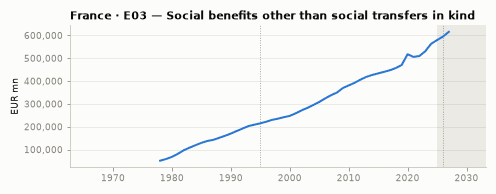

recipe:   1978-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1978-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [17]:
chart("FRA", "E03")

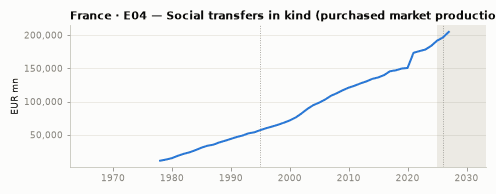

recipe:   1978-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1978-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [18]:
chart("FRA", "E04")

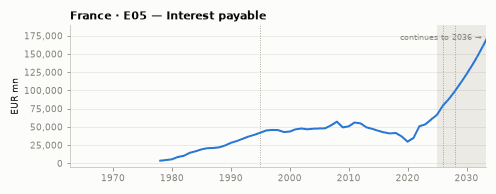

recipe:   1978-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)  ·
          2028-2036: official forecast (EC_DSM, grade B)
outturn:  1978-2025
both:     projects to 2036 — source horizon: EC_DSM ends 2036 (V10)


In [19]:
chart("FRA", "E05")

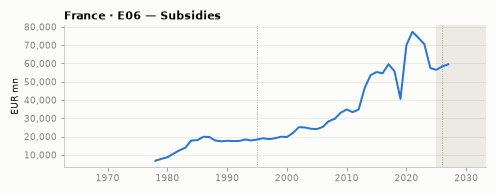

recipe:   1978-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1978-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [20]:
chart("FRA", "E06")

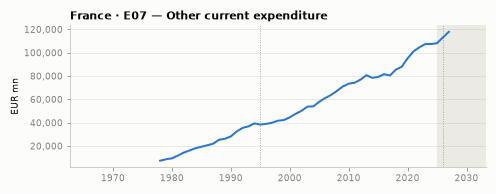

recipe:   1978-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: derived by identity
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1978-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [21]:
chart("FRA", "E07")

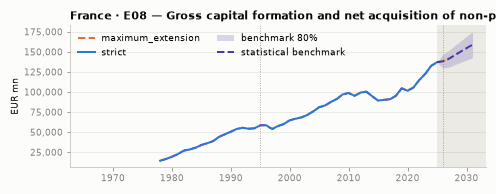

recipe:   1978-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: derived by identity
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: proxy forecast (EC_AMECO, grade B)
outturn:  1978-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict. AMECO UIGG0
          is gross fixed capital formation (P.51G) only — one component of P.5 + NP; §7.8 single-
          component proxy, applied in maximum_extension to 2027 with the measured share; no official
          forecast of inventories/valuables/non-produced assets exists
maximum:  projects to 2027 — AMECO UIGG0 is gross fixed capital formation (P.51G) only — one component
          of P.5 + NP; §7.8 single-component proxy, applied in maximum_extension to 2027 with the
          measured share; no official forecast of inventories/valuables/non-produced assets exists
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 158,905 EUR mn (80%
          142,865 to 1

In [22]:
chart("FRA", "E08")

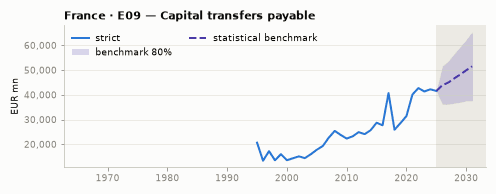

recipe:   1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
both:     NO PROJECTION — the only candidate covers too little of the line to enter strict. AMECO UKTGT
          (D.9 exactly) stops at the last actual; UKOG (other capital expenditure incl. capital
          transfers) is the forecast candidate — a superset proxy (§7.8), maximum_extension only where
          its measured share is in band
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 51,538 EUR mn (80%
          37,606 to 65,471), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [23]:
chart("FRA", "E09")

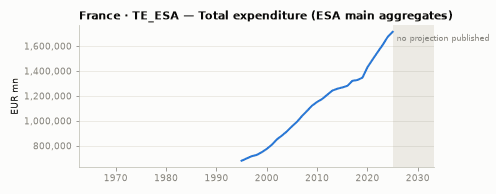

recipe:   1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
both:     NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): the same TE envelope constrains the ESA_EXP forecast sum in V15; not
          published as a stitched path


In [24]:
chart("FRA", "TE_ESA")

## 3. Germany — expenditure by ESA economic type

The forecast panel first, then nine economic lines and their total. `E03` (cash social benefits) and `E05` (interest) are the two that other publications forecast directly; read `E05` against `GF01_7` in the main book.

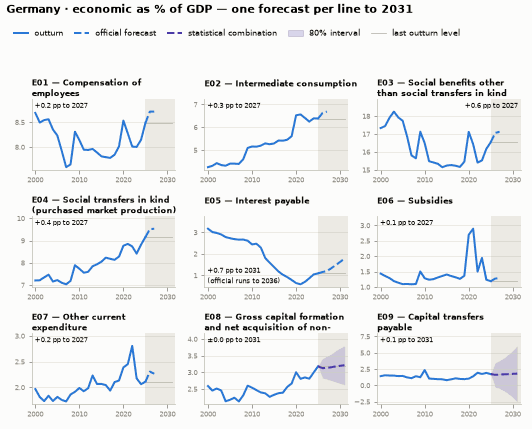

9 lines, one per ESA economic type, from 2000: 7 carry an official projection, 2 take the statistical combination. Levels, seams and the recipe behind each line are in the per-series charts below.


In [25]:
panel("DEU", "economic")

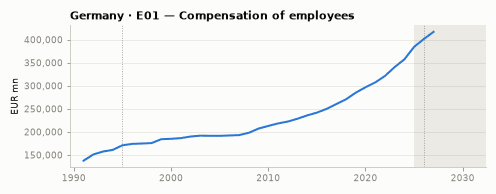

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1991-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [26]:
chart("DEU", "E01")

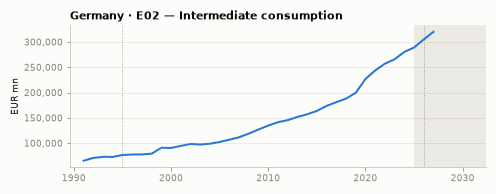

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1991-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [27]:
chart("DEU", "E02")

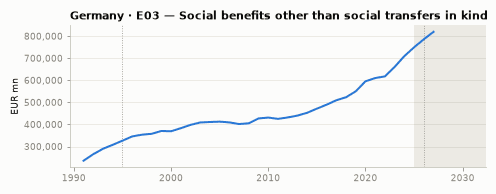

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1991-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [28]:
chart("DEU", "E03")

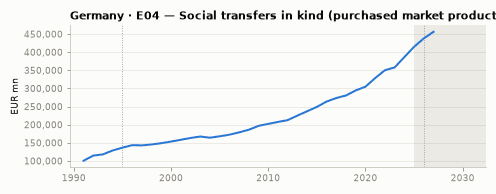

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1991-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [29]:
chart("DEU", "E04")

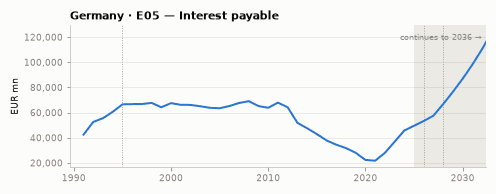

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)  ·
          2028-2036: official forecast (EC_DSM, grade B)
outturn:  1991-2025
both:     projects to 2036 — source horizon: EC_DSM ends 2036 (V10)


In [30]:
chart("DEU", "E05")

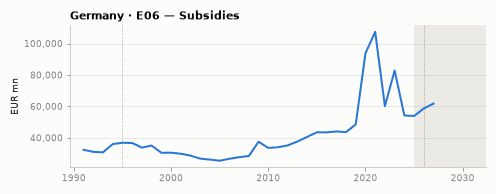

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1991-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [31]:
chart("DEU", "E06")

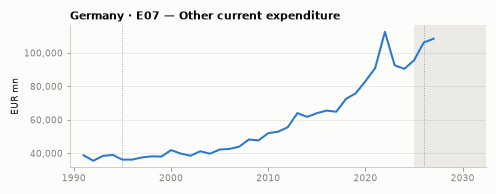

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: derived by identity
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1991-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [32]:
chart("DEU", "E07")

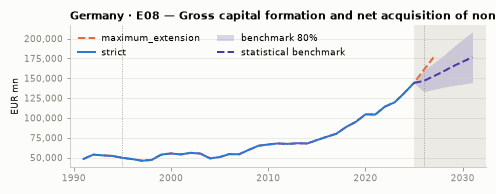

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: derived by identity
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: proxy forecast (EC_AMECO, grade B)
outturn:  1991-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict. AMECO UIGG0
          is gross fixed capital formation (P.51G) only — one component of P.5 + NP; §7.8 single-
          component proxy, applied in maximum_extension to 2027 with the measured share; no official
          forecast of inventories/valuables/non-produced assets exists
maximum:  projects to 2027 — AMECO UIGG0 is gross fixed capital formation (P.51G) only — one component
          of P.5 + NP; §7.8 single-component proxy, applied in maximum_extension to 2027 with the
          measured share; no official forecast of inventories/valuables/non-produced assets exists
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 176,460 EUR mn (80%
          144,433 to 2

In [33]:
chart("DEU", "E08")

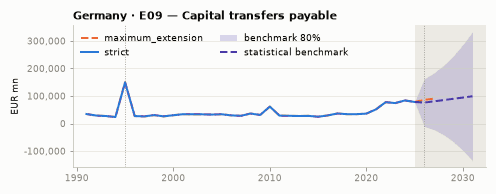

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: proxy forecast (EC_AMECO, grade B)
outturn:  1991-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict. AMECO UKTGT
          (D.9 exactly) stops at the last actual; UKOG (other capital expenditure incl. capital
          transfers) is the forecast candidate — a superset proxy (§7.8), maximum_extension only where
          its measured share is in band
maximum:  projects to 2027 — AMECO UKTGT (D.9 exactly) stops at the last actual; UKOG (other capital
          expenditure incl. capital transfers) is the forecast candidate — a superset proxy (§7.8),
          maximum_extension only where its measured share is in band
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 99,076 EUR mn (80%
          -134,875 to 333,027), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fi

In [34]:
chart("DEU", "E09")

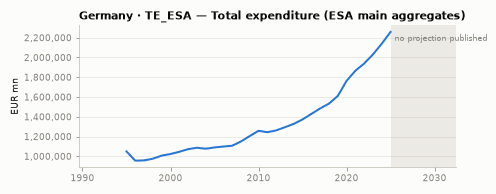

recipe:   1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
both:     NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): the same TE envelope constrains the ESA_EXP forecast sum in V15; not
          published as a stitched path


In [35]:
chart("DEU", "TE_ESA")

---

## Seams in the economic tree

The same triage table as the main book's §6, restricted to the `E` lines: every year where the source or method changes, with the year-on-year step across it.

In [36]:
rows = []
for (iso3, line), g in ECONOMIC.query("variant == 'maximum_extension'").groupby(
        ["iso3", "line_code"]):
    for year in _seams(g):
        prev = g.query("year == @year - 1").iloc[0]
        curr = g.query("year == @year").iloc[0]
        rows.append({"iso3": iso3, "line": line, "seam_year": year,
                     "from": f"{prev.observation_type} ({prev.source_id})",
                     "to": f"{curr.observation_type} ({curr.source_id})",
                     "step_pct": round(100 * (curr.value_lcu_mn
                                              / prev.value_lcu_mn - 1), 2)})
seams = pd.DataFrame(rows).sort_values(["iso3", "line", "seam_year"])
print(f"{len(seams)} seams across {seams.groupby(['iso3', 'line']).ngroups} series")
seams.reindex(seams.step_pct.abs().sort_values(ascending=False).index).reset_index(drop=True)

48 seams across 23 series


,iso3,line,seam_year,from,to,step_pct
0,DEU,E09,1995,stitched_actual (EC_AMECO),anchor_actual (EUROSTAT_GOV10A_MAIN),528.66
1,GBR,E09,1990,stitched_actual (EC_AMECO),anchor_actual (ONS_GG_RECEIPTS),191.07
2,GBR,E08,1990,stitched_actual (EC_AMECO),derived_actual (ONS_GG_RECEIPTS),21.99
3,FRA,E05,2026,anchor_actual (EUROSTAT_GOV10A_MAIN),direct_forecast (EC_AMECO),19.04
4,DEU,E05,2028,direct_forecast (EC_AMECO),direct_forecast (EC_DSM),15.99
5,GBR,E04,1990,stitched_actual (EC_AMECO),anchor_actual (ONS_GG_RECEIPTS),13.15
6,FRA,E05,2028,direct_forecast (EC_AMECO),direct_forecast (EC_DSM),11.97
7,DEU,E08,2026,derived_actual (EUROSTAT_GOV10A_MAIN),proxy_forecast (EC_AMECO),11.23
8,DEU,E07,2026,derived_actual (EUROSTAT_GOV10A_MAIN),direct_forecast (EC_AMECO),11.11
9,GBR,E06,1990,stitched_actual (EC_AMECO),anchor_actual (ONS_GG_RECEIPTS),10.77
